In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
# --- Step 1: Fetch Institutional Data ---
TICKERS = ["ADANIPOWER.NS", "PCBL.NS", "FEDERALBNK.NS", "HIKAL.NS", "IDFCFIRSTB.NS"]
print(f"📡 Fetching 2 years of daily data for {len(TICKERS)} assets...")
data = yf.download(TICKERS, period="2y")['Close'].dropna()

# Calculate daily returns
returns = data.pct_change().dropna()

📡 Fetching 2 years of daily data for 5 assets...


[*********************100%***********************]  5 of 5 completed


In [3]:
# --- Step 2: Risk Metrics Engine ---
def calculate_risk_metrics(returns_df, risk_free_rate=0.07):
    print("\n🏦 --- INSTITUTIONAL RISK REPORT ---")

    daily_rf = risk_free_rate / 252
    metrics = []

    for col in returns_df.columns:
        col_returns = returns_df[col]

        # 1. Annualized Return & Volatility
        ann_return = col_returns.mean() * 252
        ann_volatility = col_returns.std() * np.sqrt(252)

        # 2. Sharpe Ratio
        excess_return = col_returns.mean() - daily_rf
        sharpe = (excess_return / col_returns.std()) * np.sqrt(252)

        # 3. Sortino Ratio (Downside deviation only)
        downside_returns = col_returns[col_returns < 0]
        down_stdev = downside_returns.std() * np.sqrt(252)
        sortino = (ann_return - risk_free_rate) / down_stdev if down_stdev > 0 else 0

        # 4. Value at Risk (VaR) - 95% Confidence Historical
        var_95 = np.percentile(col_returns, 5)

        # 5. Maximum Drawdown
        cum_returns = (1 + col_returns).cumprod()
        rolling_max = cum_returns.cummax()
        drawdowns = (cum_returns - rolling_max) / rolling_max
        max_dd = drawdowns.min()

        metrics.append({
            "Asset": col,
            "CAGR": f"{ann_return*100:.2f}%",
            "Volatility": f"{ann_volatility*100:.2f}%",
            "Sharpe": round(sharpe, 2),
            "Sortino": round(sortino, 2),
            "VaR (95%)": f"{var_95*100:.2f}%",
            "Max Drawdown": f"{max_dd*100:.2f}%"
        })

    metrics_df = pd.DataFrame(metrics).set_index("Asset")
    print(metrics_df.to_string())
    return metrics_df

In [4]:
risk_summary = calculate_risk_metrics(returns)


🏦 --- INSTITUTIONAL RISK REPORT ---
                 CAGR Volatility  Sharpe  Sortino VaR (95%) Max Drawdown
Asset                                                                   
ADANIPOWER.NS  21.26%     46.85%    0.30     0.53    -3.25%      -49.95%
FEDERALBNK.NS  38.51%     25.35%    1.24     2.00    -2.24%      -18.07%
HIKAL.NS       -8.76%     40.23%   -0.39    -0.70    -3.69%      -59.45%
IDFCFIRSTB.NS  -4.55%     29.40%   -0.39    -0.51    -2.50%      -37.63%
PCBL.NS        11.31%     43.53%    0.10     0.17    -3.83%      -53.61%


In [5]:
# --- Step 3: Monte Carlo Portfolio Optimization ---
def optimize_portfolio(returns_df, num_portfolios=5000):
    print(f"\n🎲 Running Monte Carlo Simulation ({num_portfolios} portfolios)...")

    num_assets = len(returns_df.columns)
    results = np.zeros((3, num_portfolios))
    weights_record = []

    # Covariance matrix for portfolio risk calculation
    cov_matrix = returns_df.cov() * 252

    for i in range(num_portfolios):
        # Generate random weights that sum to 1
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)
        weights_record.append(weights)

        # Expected Portfolio Return & Volatility
        port_return = np.sum(returns_df.mean() * weights) * 252
        port_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

        # Store Results: [0] Return, [1] Volatility, [2] Sharpe
        results[0,i] = port_return
        results[1,i] = port_std_dev
        results[2,i] = (port_return - 0.07) / port_std_dev # Assuming 7% Risk-Free Rate

    # Find the portfolio with the highest Sharpe Ratio
    max_sharpe_idx = np.argmax(results[2])
    optimal_weights = weights_record[max_sharpe_idx]

    print("\n🎯 --- OPTIMAL PORTFOLIO WEIGHTS (Max Sharpe) ---")
    for i, ticker in enumerate(returns_df.columns):
        print(f"  {ticker}: {optimal_weights[i]*100:.1f}%")

    return results, max_sharpe_idx

In [6]:
mc_results, best_idx = optimize_portfolio(returns)


🎲 Running Monte Carlo Simulation (5000 portfolios)...

🎯 --- OPTIMAL PORTFOLIO WEIGHTS (Max Sharpe) ---
  ADANIPOWER.NS: 2.8%
  FEDERALBNK.NS: 81.3%
  HIKAL.NS: 6.9%
  IDFCFIRSTB.NS: 6.9%
  PCBL.NS: 2.1%


In [7]:
# --- Step 4: Institutional Dashboards (Visuals) ---
plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 8))

<Figure size 1600x800 with 0 Axes>

Text(0.5, 1.0, 'Asset Correlation Heatmap')

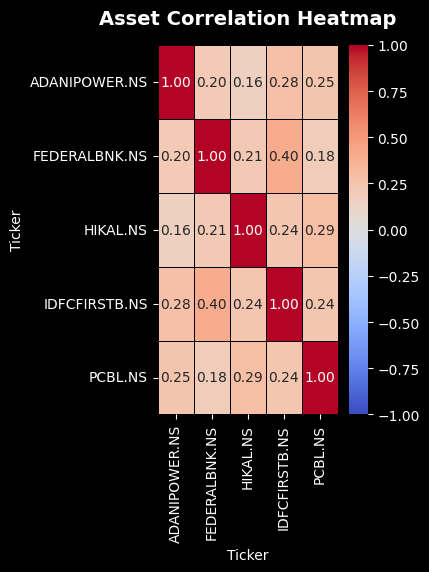

In [8]:
# Subplot 1: Asset Correlation Heatmap
ax1 = plt.subplot(1, 2, 1)
correlation_matrix = returns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, linecolor='black', ax=ax1, fmt=".2f")
ax1.set_title("Asset Correlation Heatmap", fontsize=14, fontweight='bold', pad=15)

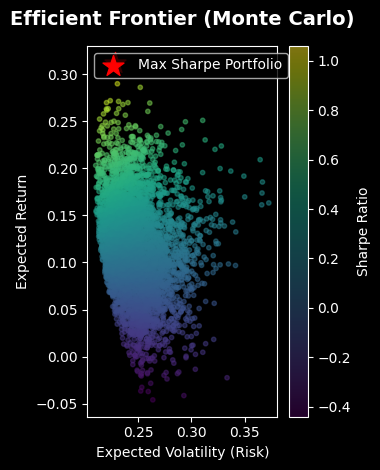

In [10]:
# Subplot 2: Efficient Frontier (Monte Carlo)
ax2 = plt.subplot(1, 2, 2)
# Scatter plot of simulated portfolios
scatter = ax2.scatter(mc_results[1,:], mc_results[0,:], c=mc_results[2,:],
                      cmap='viridis', marker='o', s=10, alpha=0.5)
# Mark the optimal portfolio
ax2.scatter(mc_results[1, best_idx], mc_results[0, best_idx],
            color='red', marker='*', s=250, label='Max Sharpe Portfolio', zorder=5)

ax2.set_title("Efficient Frontier (Monte Carlo)", fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("Expected Volatility (Risk)")
ax2.set_ylabel("Expected Return")
fig.colorbar(scatter, ax=ax2, label='Sharpe Ratio')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()